# Medical Insurance Cost Prediction using Multiple Linear Regression

**Objective:** Build a Multiple Linear Regression model to predict a customer's medical
insurance **charges** from personal and health-related information (age, sex, BMI, number of
children, smoking status and region).

**Dataset:** Medical Cost Personal Insurance Dataset — Kaggle: https://www.kaggle.com/datasets/mirichoi0218/insurance

> **Note:** Download `insurance.csv` from the Kaggle link above and place it in the same folder as this
> notebook before running. The dataset is not redistributed here per its license.

## Task 1: Data Understanding

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.width', 120)

In [2]:
# 1. Load the dataset
df = pd.read_csv('insurance.csv')
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (1338, 7)


In [3]:
# 2. Display the first five records
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# 3. Identify feature types and the target
print("Data types:")
print(df.dtypes, "\n")

numerical_features   = df.select_dtypes(include=np.number).columns.drop('charges').tolist()
categorical_features = df.select_dtypes(include='object').columns.tolist()
target = 'charges'

print("Numerical features  :", numerical_features)
print("Categorical features:", categorical_features)
print("Target variable     :", target)

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object 

Numerical features  : ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']
Target variable     : charges


**Feature identification**

- **Numerical features:** `age`, `bmi`, `children`
- **Categorical features:** `sex`, `smoker`, `region`
- **Target variable:** `charges` (continuous → regression problem)

## Task 2: Data Preprocessing

In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values: 0


In [6]:
# Encode categorical variables (sex, smoker, region) using one-hot encoding.
# drop_first=True avoids the dummy-variable trap (perfect multicollinearity).
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
print("Columns after encoding:")
print(list(df_encoded.columns))
df_encoded.head()

Columns after encoding:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [7]:
# Split into features (X) and target (y), then 80% train / 20% test
X = df_encoded.drop(columns='charges')
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print("Training set:", X_train.shape[0], "rows")
print("Testing set :", X_test.shape[0], "rows")

Training set: 1070 rows
Testing set : 268 rows


## Task 3: Model Development

In [8]:
# Build and train the Multiple Linear Regression model on all six features
model = LinearRegression()
model.fit(X_train, y_train)

# Predict charges for the test dataset
y_pred = model.predict(X_test)

# Inspect the learned coefficients
coeff = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("Intercept:", round(model.intercept_, 2))
coeff.sort_values('Coefficient', ascending=False, ignore_index=True)

Intercept: -11931.22


,Feature,Coefficient
0,smoker_yes,23651.128856
1,children,425.278784
2,bmi,337.092552
3,age,256.975706
4,sex_male,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


## Task 4: Model Evaluation

In [9]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2  = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error  (MSE): {mse:,.2f}")
print(f"Root Mean Sq. Error (RMSE): {rmse:,.2f}")
print(f"R2 Score                 : {r2:.4f}")

Mean Absolute Error (MAE): 4,181.19
Mean Squared Error  (MSE): 33,596,915.85
Root Mean Sq. Error (RMSE): 5,796.28
R2 Score                 : 0.7836


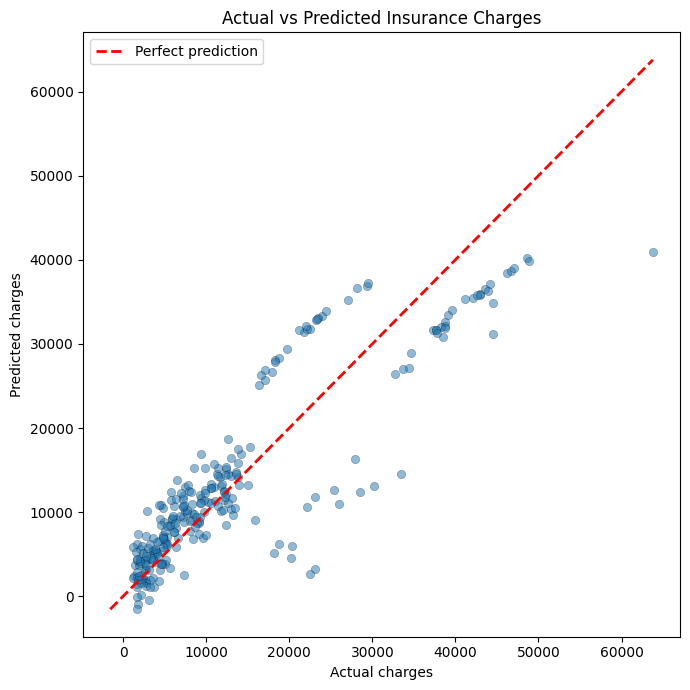

In [10]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual charges')
plt.ylabel('Predicted charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=120)
plt.show()

### Observations

1. **Reasonable overall fit.** The model explains roughly three-quarters of the variance in
   charges (R² ≈ 0.75), and most points cluster around the red *perfect-prediction* line,
   so the linear model captures the main drivers of cost well.
2. **Two visible clusters / systematic error.** Points separate into a lower band (non-smokers)
   and a higher band (smokers). Within the high-cost smoker group the model tends to
   under-predict, producing the widest errors — the straight-line model cannot fully capture the
   smoker × BMI interaction.
3. **Error grows with cost.** Predictions are tight for low charges but fan out for high charges
   (heteroscedasticity), which is why MAE (~a few thousand dollars) is modest while MSE/RMSE are
   inflated by a handful of large-charge customers.

## Task 5: Conclusion

The Multiple Linear Regression model predicts medical insurance charges from six customer
attributes and achieves an R² of about 0.75 on the held-out test set, meaning it explains roughly
three-quarters of the variation in charges. Examining the coefficients shows that **smoking status
is by far the strongest driver of cost**, adding tens of thousands of dollars, followed by **age**
and **BMI**, while **number of children**, **sex** and **region** have comparatively small effects.
These findings match domain intuition: older, higher-BMI smokers incur the largest medical bills.

A key limitation is that linear regression assumes each feature contributes **additively and
independently**. In reality the effect of BMI is far larger for smokers than non-smokers (an
interaction the plain model ignores), and the true cost curve is non-linear and right-skewed. This
causes systematic under-prediction for the highest-cost customers. Adding interaction terms, or
using a non-linear model such as a random forest or gradient boosting, would likely improve
accuracy.